In [1]:
import pandas as pd
import numpy as np

pd.options.plotting.backend = "plotly"

In [2]:
train = pd.read_csv('train.csv')
valid = pd.read_csv('test.csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


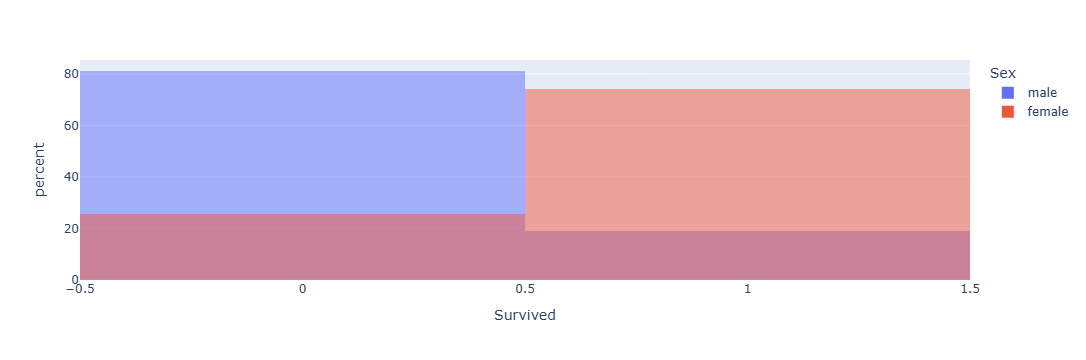

In [4]:
train.plot(kind='hist', x='Survived', color='Sex', barmode='overlay', histnorm='percent')

In [5]:
X = train.drop(columns=['Survived'])
y = train['Survived']

In [6]:
np.mean((X['Sex'] == 'female').astype(int) == y)

np.float64(0.7867564534231201)

In [7]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [8]:
X_select = X[['Pclass', 'SibSp', 'Parch', 'Fare']]

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
knn.fit(X_select, y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [11]:
np.mean(knn.predict(X_select) == y)

np.float64(0.7643097643097643)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_select, y, test_size=0.2, random_state=42)

In [13]:
knn.fit(X_train, y_train)
np.mean(knn.predict(X_test) == y_test)

np.float64(0.6703910614525139)

In [14]:
knn.score(X_test, y_test)

0.6703910614525139

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

cv_scores = cross_val_score(knn, X_select, y, cv=skf)
cv_scores, np.mean(cv_scores)

(array([0.66480447, 0.6741573 , 0.61235955, 0.60674157, 0.69662921]),
 np.float64(0.6509384219446362))

In [16]:
scores = []

for i, (train_index, test_index) in enumerate(skf.split(X_select, y)):
    X_train, X_test = X_select.iloc[train_index], X_select.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    knn.fit(X_train, y_train)
    score = np.mean(knn.predict(X_test) == y_test)
    scores.append(score)
    print(f"Fold n°{i}: {score}")

np.mean(scores)

Fold n°0: 0.664804469273743
Fold n°1: 0.6741573033707865
Fold n°2: 0.6123595505617978
Fold n°3: 0.6067415730337079
Fold n°4: 0.6966292134831461


np.float64(0.6509384219446362)

In [17]:
scores = []

for i, (train_index, test_index) in enumerate(skf.split(X_select, y)):
    X_train, X_test = X_select.iloc[train_index], X_select.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    score = np.mean(knn.predict(X_test) == y_test)
    scores.append(score)
    print(f"Fold n°{i}: {score}")

np.mean(scores)

Fold n°0: 0.6536312849162011
Fold n°1: 0.702247191011236
Fold n°2: 0.6685393258426966
Fold n°3: 0.6404494382022472
Fold n°4: 0.7078651685393258


np.float64(0.6745464817023412)

In [18]:
from sklearn.linear_model import LogisticRegression

scores = []

for i, (train_index, test_index) in enumerate(skf.split(X_select, y)):
    X_train, X_test = X_select.iloc[train_index], X_select.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LogisticRegression()
    model.fit(X_train, y_train)
    score = np.mean(model.predict(X_test) == y_test)
    scores.append(score)
    print(f"Fold n°{i}: {score}")

np.mean(scores)

Fold n°0: 0.659217877094972
Fold n°1: 0.6966292134831461
Fold n°2: 0.702247191011236
Fold n°3: 0.6910112359550562
Fold n°4: 0.6629213483146067


np.float64(0.6824053731718034)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_select, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
p = model.predict_proba(X_test)[:, 1]

In [21]:
(p >= 0.5).astype(int) == model.predict(X_test)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

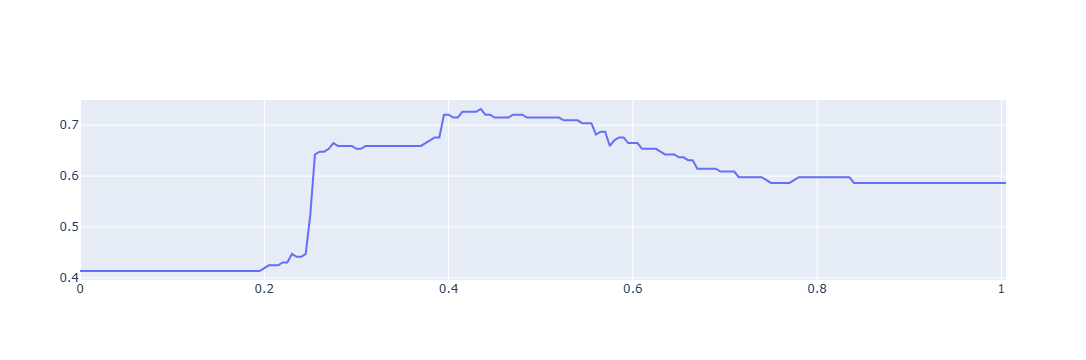

In [22]:
import plotly.graph_objects as go

thresholds = np.arange(0, 1.01, 0.005)
accuracies = [np.mean((p >= t) == y_test) for t in thresholds]

fig = go.Figure(data=go.Scatter(x=thresholds, y=accuracies))
fig.show()

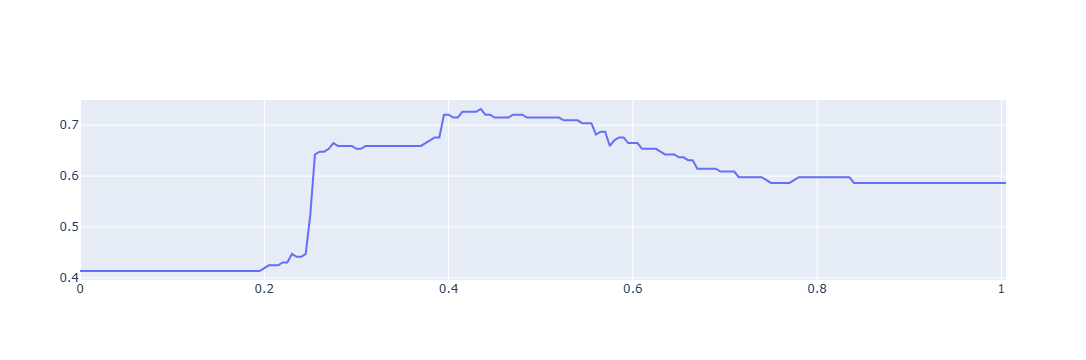

In [23]:
from sklearn.metrics import accuracy_score

thresholds = np.arange(0, 1.01, 0.005)
accuracies = [accuracy_score(y_test, p >= t) for t in thresholds]

fig = go.Figure(data=go.Scatter(x=thresholds, y=accuracies))
fig.show()

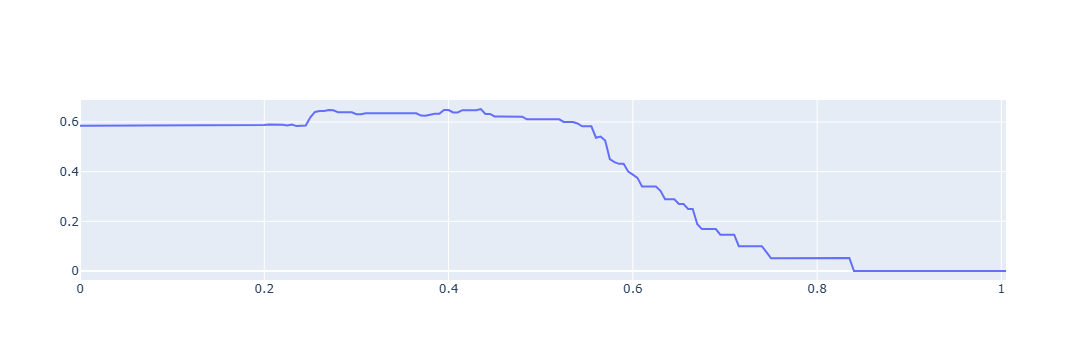

In [24]:
from sklearn.metrics import f1_score

thresholds = np.arange(0, 1.01, 0.005)
f1s = [f1_score(y_test, p >= t) for t in thresholds]

fig = go.Figure(data=go.Scatter(x=thresholds, y=f1s))
fig.show()

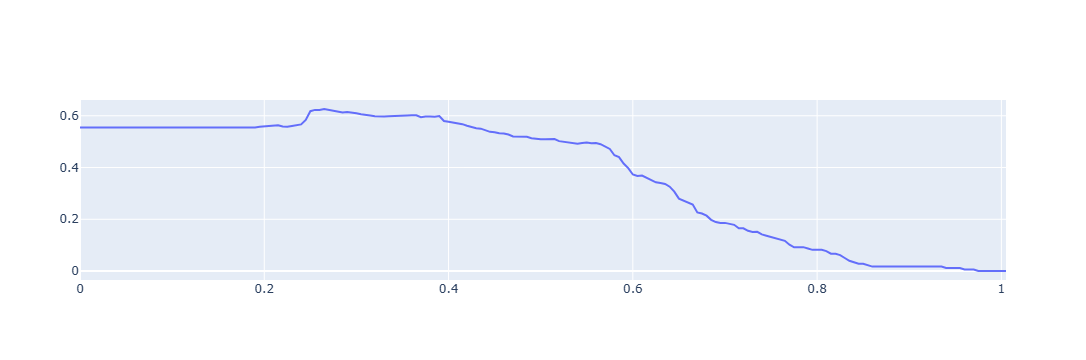

In [25]:
thresholds = np.arange(0, 1.01, 0.005)

f1s = []

for t in thresholds:
    f1s_t = []

    for i, (train_index, test_index) in enumerate(skf.split(X_select, y)):
        X_train, X_test = X_select.iloc[train_index], X_select.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
        model = LogisticRegression()
        model.fit(X_train, y_train)
        p = model.predict_proba(X_test)[:, 1]

        f1s_t.append(f1_score(y_test, p >= t))

    f1s.append(np.mean(f1s_t))

fig = go.Figure(data=go.Scatter(x=thresholds, y=f1s))
fig.show()

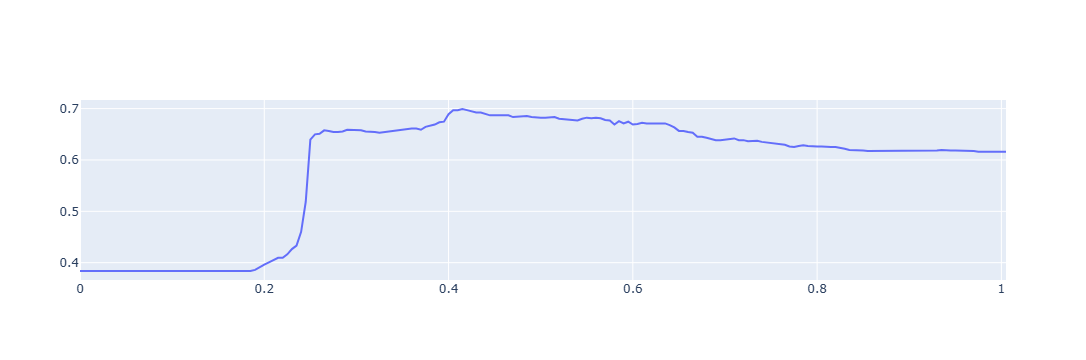

In [26]:
thresholds = np.arange(0, 1.01, 0.005)

accuracies = []

for t in thresholds:
    accuracies_t = []

    for i, (train_index, test_index) in enumerate(skf.split(X_select, y)):
        X_train, X_test = X_select.iloc[train_index], X_select.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
        model = LogisticRegression()
        model.fit(X_train, y_train)
        p = model.predict_proba(X_test)[:, 1]

        accuracies_t.append(accuracy_score(y_test, p >= t))

    accuracies.append(np.mean(accuracies_t))

fig = go.Figure(data=go.Scatter(x=thresholds, y=accuracies))
fig.show()

In [27]:
thresholds[np.argmax(accuracies)]

np.float64(0.41500000000000004)

In [28]:
scores = []

for i, (train_index, test_index) in enumerate(skf.split(X_select, y)):
    X_train, X_test = X_select.iloc[train_index], X_select.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = LogisticRegression()
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    prediction = np.where(p >= 0.415, 1, 0)
    score = np.mean(prediction == y_test)
    scores.append(score)
    print(f"Fold n°{i}: {score}")

np.mean(scores)

Fold n°0: 0.6759776536312849
Fold n°1: 0.7247191011235955
Fold n°2: 0.6966292134831461
Fold n°3: 0.7078651685393258
Fold n°4: 0.6910112359550562


np.float64(0.6992404745464815)

In [29]:
X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
X.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [31]:
valid.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

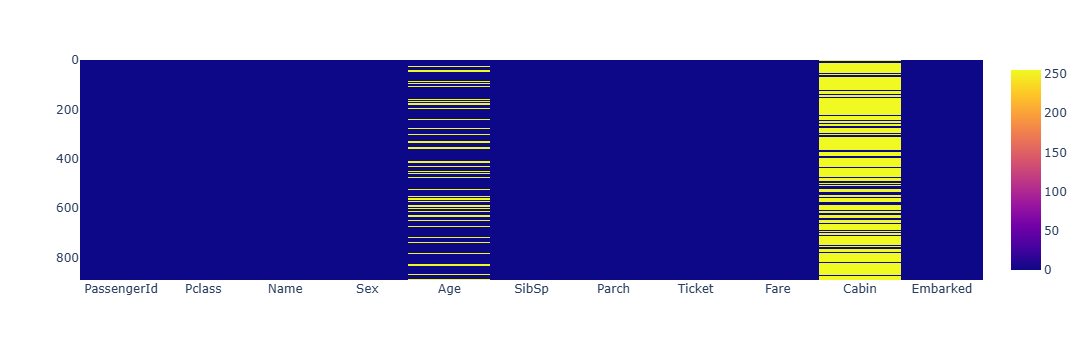

In [32]:
X.isna().plot(kind='imshow')

In [33]:
X['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [34]:
X['Age'].fillna(X['Age'].mean())

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

In [35]:
X['Age']


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [36]:
X.select_dtypes("number").corr().abs()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,0.035144,0.036847,0.057527,0.001652,0.012658
Pclass,0.035144,1.000000,0.369226,0.083081,0.018443,0.549500
Age,0.036847,0.369226,1.000000,0.308247,0.189119,0.096067
SibSp,0.057527,0.083081,0.308247,1.000000,0.414838,0.159651
Parch,0.001652,0.018443,0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.549500,0.096067,0.159651,0.216225,1.000000


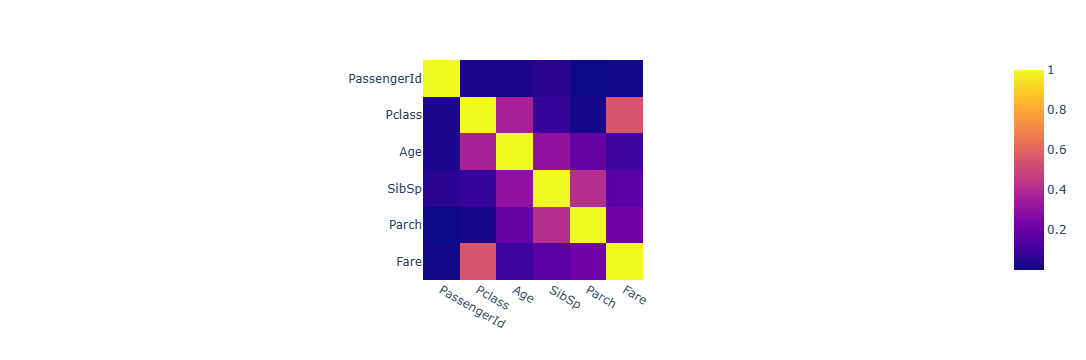

In [37]:
X.select_dtypes("number").corr().abs().plot(kind="imshow")

In [38]:
X['Sex'] = X['Sex'].eq('female').astype(int)
valid['Sex'] = valid['Sex'].eq('female').astype(int)

In [39]:
X.select_dtypes("number").corr().abs()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare
PassengerId,1.000000,0.035144,0.042939,0.036847,0.057527,0.001652,0.012658
Pclass,0.035144,1.000000,0.131900,0.369226,0.083081,0.018443,0.549500
Sex,0.042939,0.131900,1.000000,0.093254,0.114631,0.245489,0.182333
Age,0.036847,0.369226,0.093254,1.000000,0.308247,0.189119,0.096067
SibSp,0.057527,0.083081,0.114631,0.308247,1.000000,0.414838,0.159651
Parch,0.001652,0.018443,0.245489,0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.549500,0.182333,0.096067,0.159651,0.216225,1.000000


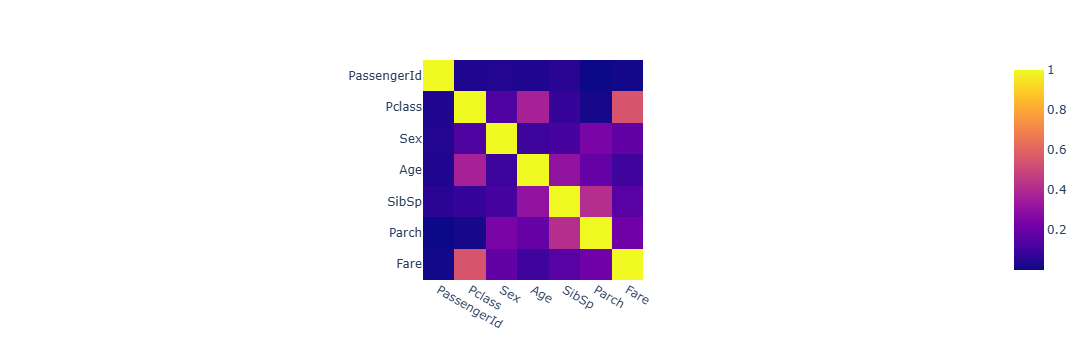

In [40]:
X.select_dtypes("number").corr().abs().plot(kind="imshow")

In [41]:
X.groupby(['Pclass', 'Sex'])['Age'].mean()

Pclass  Sex
1       0      41.281386
        1      34.611765
2       0      30.740707
        1      28.722973
3       0      26.507589
        1      21.750000
Name: Age, dtype: float64

In [42]:
X[['Pclass', 'Sex', 'Age']]

,Pclass,Sex,Age
0,3,0,22.0
1,1,1,38.0
2,3,1,26.0
3,1,1,35.0
4,3,0,35.0
...,...,...,...
886,2,0,27.0
887,1,1,19.0
888,3,1,NaN
889,1,0,26.0


In [43]:
X.groupby(['Pclass', 'Sex'])['Age'].transform('mean')

0      26.507589
1      34.611765
2      21.750000
3      34.611765
4      26.507589
         ...    
886    30.740707
887    34.611765
888    21.750000
889    41.281386
890    26.507589
Name: Age, Length: 891, dtype: float64

In [44]:
X_copy = X.copy()

table = X_copy.groupby(['Pclass', 'Sex'])['Age'].mean()
table

Pclass  Sex
1       0      41.281386
        1      34.611765
2       0      30.740707
        1      28.722973
3       0      26.507589
        1      21.750000
Name: Age, dtype: float64

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

table = X_train.groupby(['Pclass', 'Sex'])['Age'].mean()
table

Pclass  Sex
1       0      40.558158
        1      34.865672
2       0      30.861446
        1      28.387931
3       0      26.640388
        1      21.451220
Name: Age, dtype: float64

In [46]:
pd.MultiIndex.from_frame(X_train[['Pclass', 'Sex']])

MultiIndex([(1, 0),
            (2, 0),
            (3, 0),
            (3, 0),
            (3, 1),
            (1, 0),
            (1, 0),
            (2, 0),
            (3, 0),
            (1, 0),
            ...
            (3, 0),
            (3, 0),
            (2, 0),
            (1, 1),
            (3, 1),
            (3, 1),
            (1, 0),
            (3, 0),
            (1, 1),
            (1, 0)],
           names=['Pclass', 'Sex'], length=712)

In [47]:
table.reindex(pd.MultiIndex.from_frame(X_train[['Pclass', 'Sex']]))

Pclass  Sex
1       0      40.558158
2       0      30.861446
3       0      26.640388
        0      26.640388
        1      21.451220
                 ...    
        1      21.451220
1       0      40.558158
3       0      26.640388
1       1      34.865672
        0      40.558158
Name: Age, Length: 712, dtype: float64

In [48]:
table.reindex(pd.MultiIndex.from_frame(X_train[['Pclass', 'Sex']])).set_axis(X_train.index)

331    40.558158
733    30.861446
382    26.640388
704    26.640388
813    21.451220
         ...    
106    21.451220
270    40.558158
860    26.640388
435    34.865672
102    40.558158
Name: Age, Length: 712, dtype: float64

In [49]:
X_train[['Pclass', 'Sex', 'Age']]

,Pclass,Sex,Age
331,1,0,45.5
733,2,0,23.0
382,3,0,32.0
704,3,0,26.0
813,3,1,6.0
...,...,...,...
106,3,1,21.0
270,1,0,NaN
860,3,0,41.0
435,1,1,14.0


In [50]:
fill_train = table.reindex(pd.MultiIndex.from_frame(X_train[['Pclass', 'Sex']])).set_axis(X_train.index)
X_train['Age'] = X_train['Age'].fillna(fill_train)

In [51]:
X_train[['Pclass', 'Sex', 'Age']]

,Pclass,Sex,Age
331,1,0,45.500000
733,2,0,23.000000
382,3,0,32.000000
704,3,0,26.000000
813,3,1,6.000000
...,...,...,...
106,3,1,21.000000
270,1,0,40.558158
860,3,0,41.000000
435,1,1,14.000000


In [52]:
fill_test = table.reindex(pd.MultiIndex.from_frame(X_test[['Pclass', 'Sex']])).set_axis(X_test.index)
X_test['Age'] = X_test['Age'].fillna(fill_test)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def fillna_mean(X_train, X_test, cat, col):
    X_train = X_train.copy()
    X_test = X_test.copy()

    table = X_train.groupby(cat)[col].mean()
    fill_train = table.reindex(pd.MultiIndex.from_frame(X_train[cat])).set_axis(X_train.index)
    fill_test = table.reindex(pd.MultiIndex.from_frame(X_test[cat])).set_axis(X_test.index)
    X_train[col] = X_train[col].fillna(fill_test)
    X_test[col] = X_test[col].fillna(fill_test)

    return X_train, X_test

X_train, X_test = fillna_mean(X_train, X_test, ['Pclass', 'Sex'], 'Age')

In [54]:
X[X['Embarked'].isna()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,"Icard, Miss. Amelie",1,38.0,0,0,113572,80.0,B28,NaN
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",1,62.0,0,0,113572,80.0,B28,NaN


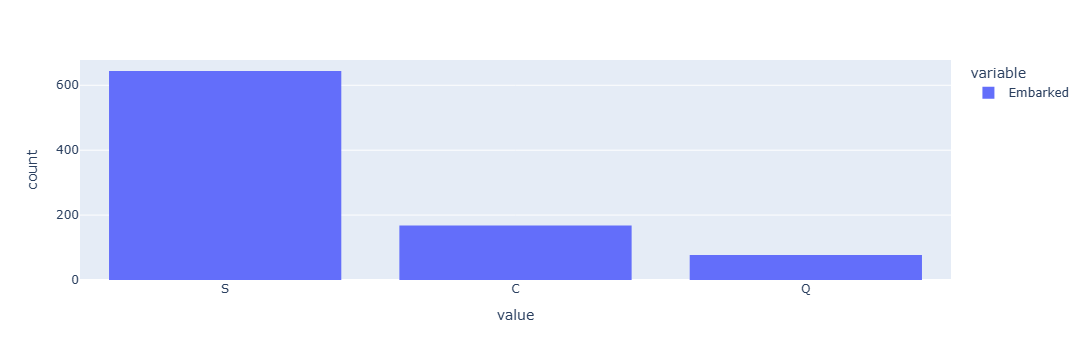

In [55]:
X['Embarked'].plot(kind='hist')

In [56]:
X['Embarked'].fillna('S', inplace=True)

In [57]:
X[X['Embarked'].isna()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [58]:
newcols = ["Pclass_2", "Pclass_3", "Embarked_Q", "Embarked_S"]

X[newcols] = pd.get_dummies(X, columns=['Pclass', 'Embarked'], drop_first=True)[newcols].astype(int)
valid[newcols] = pd.get_dummies(valid, columns=['Pclass', 'Embarked'], drop_first=True)[newcols].astype(int)

In [59]:
X.columns, X.select_dtypes("number").columns

(Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
        'Ticket', 'Fare', 'Cabin', 'Embarked', 'Pclass_2', 'Pclass_3',
        'Embarked_Q', 'Embarked_S'],
       dtype='object'),
 Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
        'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S'],
       dtype='object'))

In [70]:
scores = []

def fillna_mean(X_train, X_test, cat, col):
    X_train = X_train.copy()
    X_test = X_test.copy()
    
    table = X_train.groupby(cat)[col].mean()
    fill_train = table.reindex(pd.MultiIndex.from_frame(X_train[cat])).set_axis(X_train.index)
    fill_test = table.reindex(pd.MultiIndex.from_frame(X_test[cat])).set_axis(X_test.index)
    X_train[col] = X_train[col].fillna(fill_train)
    X_test[col] = X_test[col].fillna(fill_test)

    return X_train, X_test

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    X_train, X_test = fillna_mean(X_train, X_test, ['Pclass', 'Sex'], 'Age')

    cols = ['Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S']
    X_train, X_test = X_train[cols], X_test[cols]

    model = LogisticRegression(max_iter=10_000_000)
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    prediction = np.where(p >= 0.415, 1, 0)
    score = np.mean(prediction == y_test)
    scores.append(score)
    print(f"Fold n°{i}: {score}")

np.mean(scores)

Fold n°0: 0.770949720670391
Fold n°1: 0.8089887640449438
Fold n°2: 0.7808988764044944
Fold n°3: 0.7808988764044944
Fold n°4: 0.8202247191011236


np.float64(0.7923921913250894)

In [73]:
X['Fare'].mean()
valid['Fare'].fillna(X['Fare'].mean(), inplace=True)

/tmp/ipykernel_2365/86388643.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [74]:
X_train = X
y_train = y
X_test = valid

X_train, X_test = fillna_mean(X_train, X_test, ['Pclass', 'Sex'], 'Age')

cols = ['Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S']
X_train, X_test = X_train[cols], X_test[cols]

model = LogisticRegression(max_iter=10_000_000)
model.fit(X_train, y_train)

p = model.predict_proba(X_test)[:, 1]
prediction = np.where(p >= 0.415, 1, 0)

In [78]:
sub = valid.copy()
sub['Survived'] = prediction
sub[['PassengerId', 'Survived']].to_csv('sub.csv', index=False)

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler

scores = []

def fillna_mean(X_train, X_test, cat, col):
    X_train = X_train.copy()
    X_test = X_test.copy()
    
    table = X_train.groupby(cat)[col].mean()
    fill_train = table.reindex(pd.MultiIndex.from_frame(X_train[cat])).set_axis(X_train.index)
    fill_test = table.reindex(pd.MultiIndex.from_frame(X_test[cat])).set_axis(X_test.index)
    X_train[col] = X_train[col].fillna(fill_train)
    X_test[col] = X_test[col].fillna(fill_test)

    return X_train, X_test

for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    X_train, X_test = fillna_mean(X_train, X_test, ['Pclass', 'Sex'], 'Age')

    cols = ['Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S']
    X_train, X_test = X_train[cols], X_test[cols]

    scaler_age, scaler_fare = RobustScaler(), RobustScaler()
    scaler_age.fit(X_train[['Age']])
    scaler_fare.fit(X_train[['Fare']])
    
    X_train['Age'], X_test['Age'] = scaler_age.transform(X_train[['Age']]), scaler_age.transform(X_test[['Age']])
    X_train['Fare'], X_test['Fare'] = scaler_fare.transform(X_train[['Fare']]), scaler_fare.transform(X_test[['Fare']])
    

    model = RandomForestClassifier(n_estimators=250)
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    score = np.mean(prediction == y_test)
    scores.append(score)
    print(f"Fold n°{i}: {score}")

np.mean(scores)

Fold n°0: 0.8212290502793296
Fold n°1: 0.8089887640449438
Fold n°2: 0.8089887640449438
Fold n°3: 0.8202247191011236
Fold n°4: 0.848314606741573


np.float64(0.8215491808423827)

In [103]:
X_train = X
y_train = y
X_test = valid

X_train, X_test = fillna_mean(X_train, X_test, ['Pclass', 'Sex'], 'Age')

cols = ['Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S']
X_train, X_test = X_train[cols], X_test[cols]

scaler_age, scaler_fare = RobustScaler(), RobustScaler()
scaler_age.fit(X_train[['Age']])
scaler_fare.fit(X_train[['Fare']])
    
X_train['Age'], X_test['Age'] = scaler_age.transform(X_train[['Age']]), scaler_age.transform(X_test[['Age']])
X_train['Fare'], X_test['Fare'] = scaler_fare.transform(X_train[['Fare']]), scaler_fare.transform(X_test[['Fare']])

model = RandomForestClassifier(n_estimators=250)
model.fit(X_train, y_train)
prediction = model.predict(X_test)

In [104]:
sub = valid.copy()
sub['Survived'] = prediction
sub[['PassengerId', 'Survived']].to_csv('sub2.csv', index=False)